# 032 — Evaluation (unet_v2, unet_restormer + beta-NLL)

Evaluates the three things trained in `022_training_v2.ipynb` against their respective baselines on the held-out test set:

- **Part A**: the four `beta_nll`-trained architectures (`models/nll_beta/<arch>/`) vs. their `gaussian_nll` counterparts (`models/<arch>/`, from `021_training_nll.ipynb`) — does beta-weighting (Seitzer et al. 2022) close the mae/psnr/ssim regression documented in `code-review.md` §7.6?
- **Part B**: `unet_v2` and `unet_restormer` (`models/unet_v2/`, `models/unet_restormer/`) vs. `unet` (`models/unet/`, from `020_training.ipynb`) — do the architectural modifications (strided-conv downsampling, upsample+conv upsampling, bottleneck/first-decoder-block dropout for `unet_v2`; a Restormer self-attention block at the bottleneck for `unet_restormer`, `code-review.md` §7.3) improve on the baseline?

Mirrors `031_evaluation_nll.ipynb` (Part A) and `030_evaluation.ipynb` (Part B). Metrics for the NLL models are computed from the `mu` channel only, same as `031`.

In [1]:
import sys
from pathlib import Path

project_root = Path().absolute()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from scripts.config import settings
from scripts.dataset import (
    build_dataset,
    grouped_train_val_test_split,
    load_image_pairs,
    mockup_aware_train_val_test_split,
)
from scripts.trainer import load_model
from scripts.trainer_nll import load_model_nll
from scripts.visualization import plot_predictions

gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs available: {gpus}")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Build test dataset

In [ ]:
# Artworks split logic: every artwork ID (including the paint-on-support
# mockup groups) is a group kept entirely within a single fold, to prevent
# leakage between sections of the same painting. Must match the split used
# for training (022_training_v2.ipynb) so the test fold reported here is
# disjoint from what the loaded checkpoints were trained/validated on.
pairs = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = grouped_train_val_test_split(
    pairs,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

In [3]:
# Artwork and mockups split logic (active): must match 022_training_v2.ipynb's
# split (mockup-aware, same as 020/021) — overwrites test_pairs from the
# block above.
pairs_mockups = load_image_pairs(settings.IR_DIR, settings.RGB_DIR)
_, _, test_pairs = mockup_aware_train_val_test_split(
    pairs_mockups,
    train_ratio=settings.TRAIN_RATIO,
    val_ratio=settings.VAL_RATIO,
    mockup_ids=settings.MOCKUP_ARTWORK_IDS,
    seed=settings.SEED,
)

test_ds = build_dataset(
    test_pairs,
    batch_size=settings.BATCH_SIZE,
    augment=False,
    shuffle=False,
)
print(f"Test pairs: {len(test_pairs)} | Test batches: {len(test_ds)}")

Test pairs: 135 | Test batches: 17


2026-08-13 22:51:29.074537: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-08-13 22:51:29.074558: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-08-13 22:51:29.074562: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
2026-08-13 22:51:29.074574: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-13 22:51:29.074583: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 2. Part A — beta-NLL vs. gaussian-NLL

`loss` is the (beta-weighted or plain) Gaussian NLL — not comparable in scale to Part B's `combined_loss`. `mae`/`ssim`/`psnr` (computed from `mu`) are comparable across both loss variants and against the deterministic architectures.

In [4]:
ARCHS_NLL = ["unet_nll", "resunet_nll", "attention_unet_nll", "efficientnet_unet_nll"]
BETA_MODEL_DIR = settings.MODELS_DIR / "nll_beta"
BETA = 0.5

results_gaussian: dict = {}
results_beta: dict = {}

for arch in ARCHS_NLL:
    try:
        model_g = load_model_nll(
            arch, model_dir=settings.MODELS_DIR, loss_name="gaussian_nll"
        )
    except FileNotFoundError as exc:
        print(f"[skip gaussian_nll] {exc}")
    else:
        results_gaussian[arch] = model_g.evaluate(test_ds, verbose=0, return_dict=True)

    try:
        model_b = load_model_nll(
            arch, model_dir=BETA_MODEL_DIR, loss_name="beta_nll", beta=BETA
        )
    except FileNotFoundError as exc:
        print(f"[skip beta_nll] {exc}")
    else:
        results_beta[arch] = model_b.evaluate(test_ds, verbose=0, return_dict=True)

    g = results_gaussian.get(arch)
    b = results_beta.get(arch)
    print(f"{arch}: gaussian_nll={g}  beta_nll={b}")

2026-08-13 22:51:33.769482: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


unet_nll: gaussian_nll={'loss': -1.5121721029281616, 'mae': 0.10578420013189316, 'psnr': 19.0664005279541, 'ssim': 0.5696231722831726}  beta_nll={'loss': -0.3292178511619568, 'mae': 0.13100677728652954, 'psnr': 17.27605438232422, 'ssim': 0.4849019944667816}
resunet_nll: gaussian_nll={'loss': -1.4537618160247803, 'mae': 0.11087225377559662, 'psnr': 18.630435943603516, 'ssim': 0.4668964445590973}  beta_nll={'loss': -0.3025408685207367, 'mae': 0.16959142684936523, 'psnr': 14.99066162109375, 'ssim': 0.35773390531539917}
attention_unet_nll: gaussian_nll={'loss': -1.3829340934753418, 'mae': 0.11410818248987198, 'psnr': 18.0480899810791, 'ssim': 0.5345420837402344}  beta_nll={'loss': -0.32478711009025574, 'mae': 0.14925120770931244, 'psnr': 16.096288681030273, 'ssim': 0.4322867691516876}
efficientnet_unet_nll: gaussian_nll={'loss': -1.450476884841919, 'mae': 0.10594187676906586, 'psnr': 18.851173400878906, 'ssim': 0.5250900387763977}  beta_nll={'loss': -0.33911964297294617, 'mae': 0.111831240

## 3. Comparison table — mae / ssim / psnr, beta vs. gaussian

In [12]:
common_archs = [a for a in ARCHS_NLL if a in results_gaussian and a in results_beta]

if common_archs:
    metric_keys = ["mae", "ssim", "psnr"]
    col_w = 22
    headers = (
        ["architecture"]
        + [f"{m}_gaussian" for m in metric_keys]
        + [f"{m}_beta" for m in metric_keys]
        + [f"d_{m}" for m in metric_keys]
    )
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for arch in common_archs:
        g, b = results_gaussian[arch], results_beta[arch]
        row = [arch]
        row += [f"{g[m]:.4f}" for m in metric_keys]
        row += [f"{b[m]:.4f}" for m in metric_keys]
        row += [f"{b[m] - g[m]:+.4f}" for m in metric_keys]
        print("".join(c.ljust(col_w) for c in row))

architecture          mae_gaussian          ssim_gaussian         psnr_gaussian         mae_beta              ssim_beta             psnr_beta             d_mae                 d_ssim                d_psnr                
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
unet_nll              0.1058                0.5696                19.0664               0.1310                0.4849                17.2761               +0.0252               -0.0847               -1.7903               
resunet_nll           0.1109                0.4669                18.6304               0.1696                0.3577                14.9907               +0.0587               -0.1092               -3.6398               
attention_unet_nll    0.1141                0.5345                18.0481               0.1493                0.4323

## 4. Bar chart — beta vs. gaussian, per metric

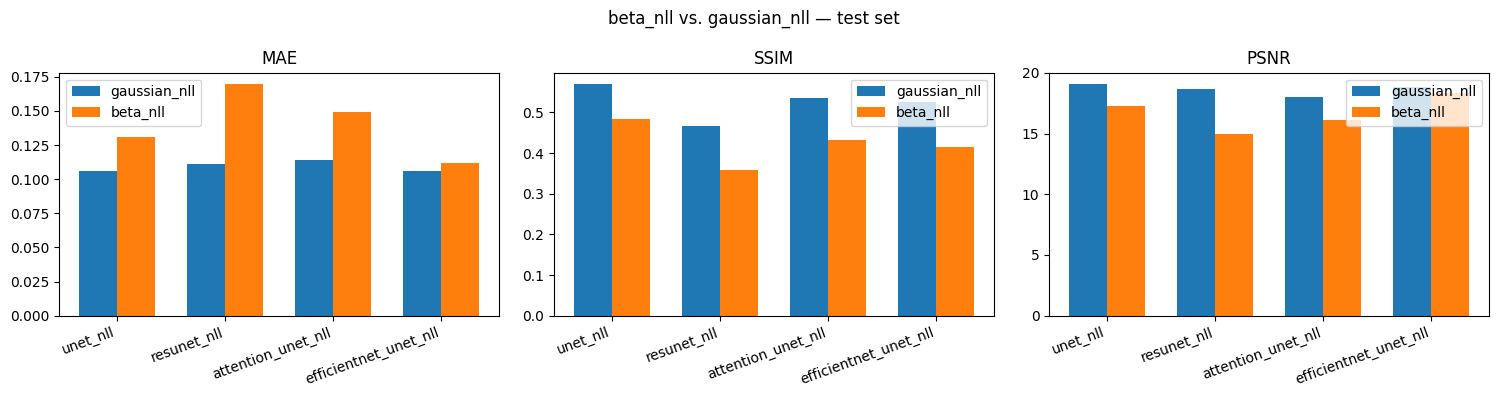

In [6]:
if common_archs:
    metric_keys = ["mae", "ssim", "psnr"]
    n = len(metric_keys)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("beta_nll vs. gaussian_nll — test set")
    x = np.arange(len(common_archs))
    width = 0.35
    for ax, key in zip(axes, metric_keys):
        g_vals = [results_gaussian[a][key] for a in common_archs]
        b_vals = [results_beta[a][key] for a in common_archs]
        ax.bar(x - width / 2, g_vals, width, label="gaussian_nll")
        ax.bar(x + width / 2, b_vals, width, label="beta_nll")
        ax.set_title(key.upper())
        ax.set_xticks(x)
        ax.set_xticklabels(common_archs, rotation=20, ha="right")
        ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Part B — unet_v2, unet_restormer vs. unet

In [7]:
DET_ARCHS = ["unet", "unet_v2", "unet_restormer"]
results_det: dict = {}

for arch in DET_ARCHS:
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"Evaluating {arch}...")
    metrics = model.evaluate(test_ds, verbose=0, return_dict=True)
    results_det[arch] = metrics
    print(f"  {arch}: { {k: f'{v:.4f}' for k, v in metrics.items()} }")

Evaluating unet...
  unet: {'loss': '0.2127', 'mae': '0.1105', 'psnr': '18.6442', 'ssim': '0.5489'}
Evaluating unet_v2...
  unet_v2: {'loss': '0.1944', 'mae': '0.1030', 'psnr': '19.4879', 'ssim': '0.5922'}
Evaluating unet_restormer...
  unet_restormer: {'loss': '0.2004', 'mae': '0.1073', 'psnr': '19.0608', 'ssim': '0.5826'}


## 6. Comparison table

In [8]:
if results_det:
    col_w = 16
    headers = ["architecture"] + list(next(iter(results_det.values())).keys())
    print("".join(h.ljust(col_w) for h in headers))
    print("-" * (col_w * len(headers)))
    for arch, metrics in results_det.items():
        row = [arch] + [f"{v:.4f}" for v in metrics.values()]
        print("".join(c.ljust(col_w) for c in row))

architecture    loss            mae             psnr            ssim            
--------------------------------------------------------------------------------
unet            0.2127          0.1105          18.6442         0.5489          
unet_v2         0.1944          0.1030          19.4879         0.5922          
unet_restormer  0.2004          0.1073          19.0608         0.5826          


## 7. Bar chart comparison

/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_8939/3900253266.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_8939/3900253266.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_8939/3900253266.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(archs, rotation=20, ha="right")
/var/folders/ql/9bx91jqj64g8vrjsm0w9qblm0000gn/T/ipykernel_8939/3900253266.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
 

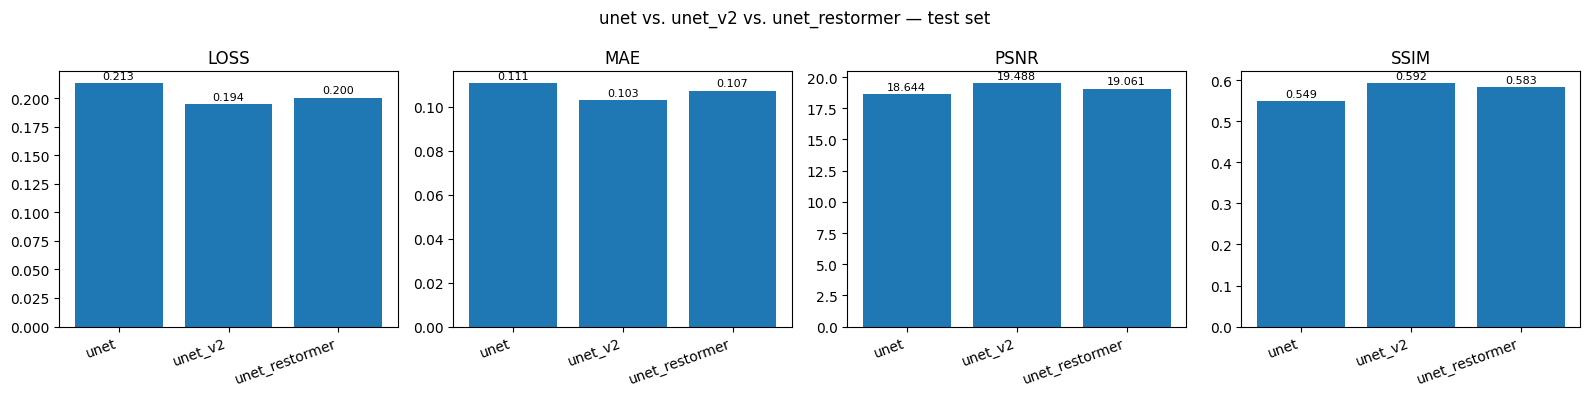

In [9]:
if results_det:
    metric_keys = list(next(iter(results_det.values())).keys())
    n = len(metric_keys)
    archs = list(results_det.keys())
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    fig.suptitle("unet vs. unet_v2 vs. unet_restormer — test set")
    for ax, key in zip(axes, metric_keys):
        vals = [results_det[a][key] for a in archs]
        bars = ax.bar(archs, vals)
        ax.set_title(key.upper())
        ax.set_xticklabels(archs, rotation=20, ha="right")
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() * 1.01,
                f"{v:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()

## 8. Qualitative gallery — unet_v2 / unet_restormer, 5 test samples


--- unet_v2 ---


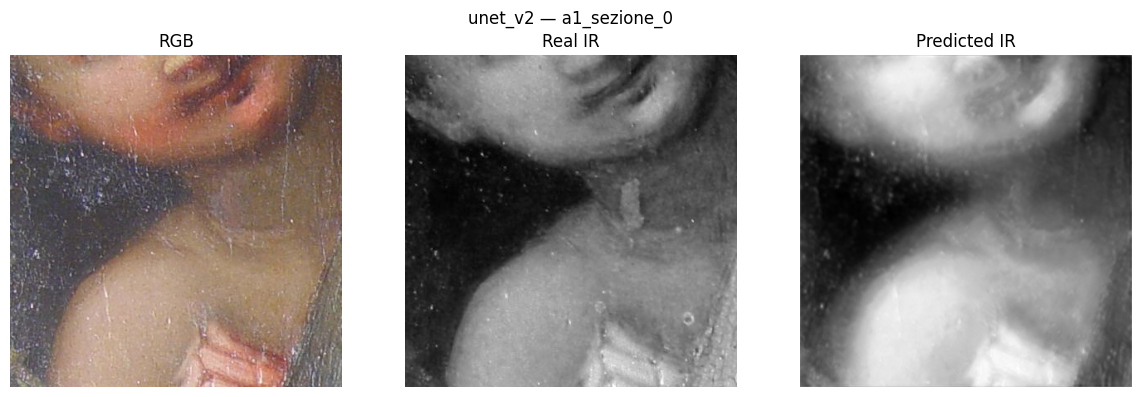

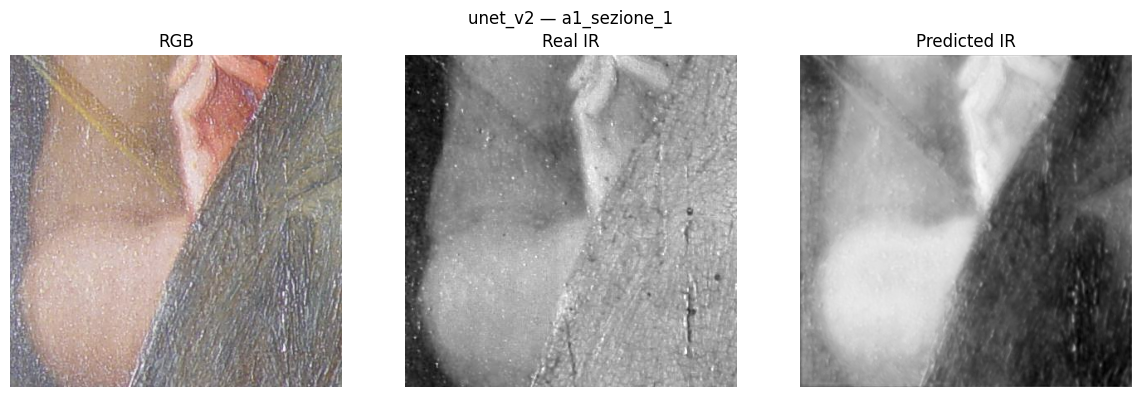

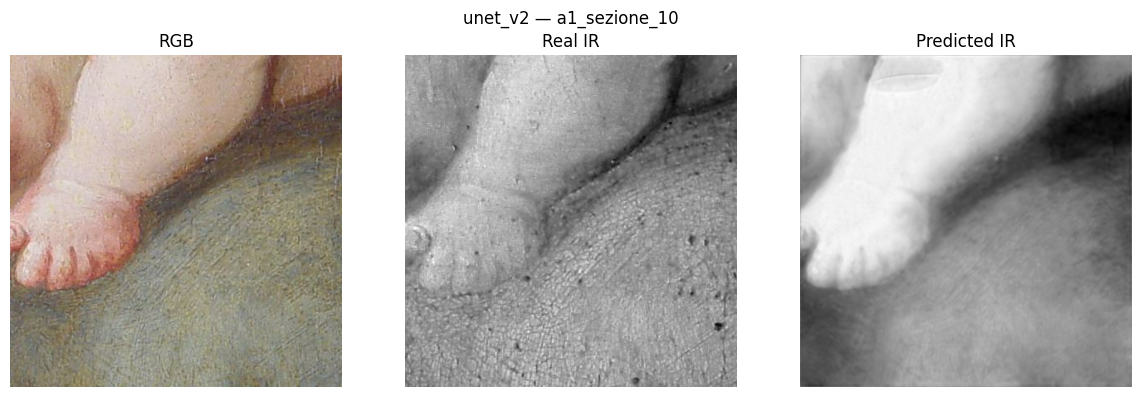

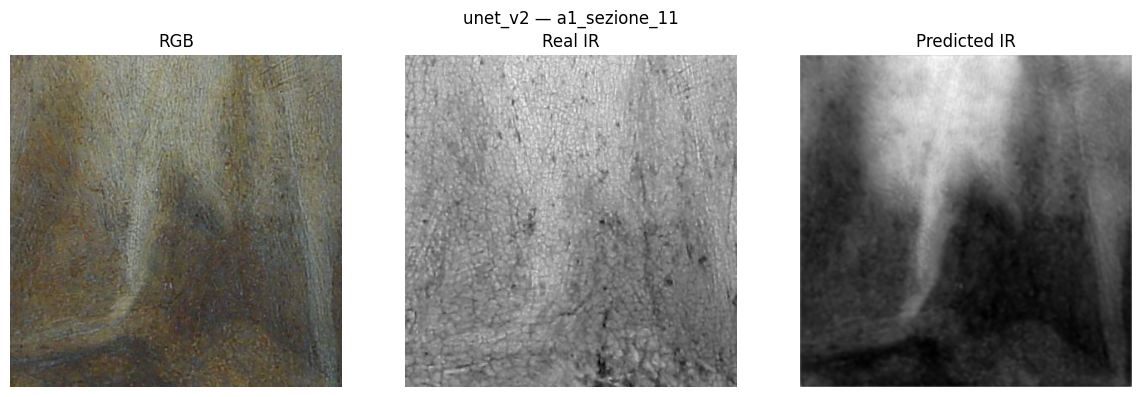

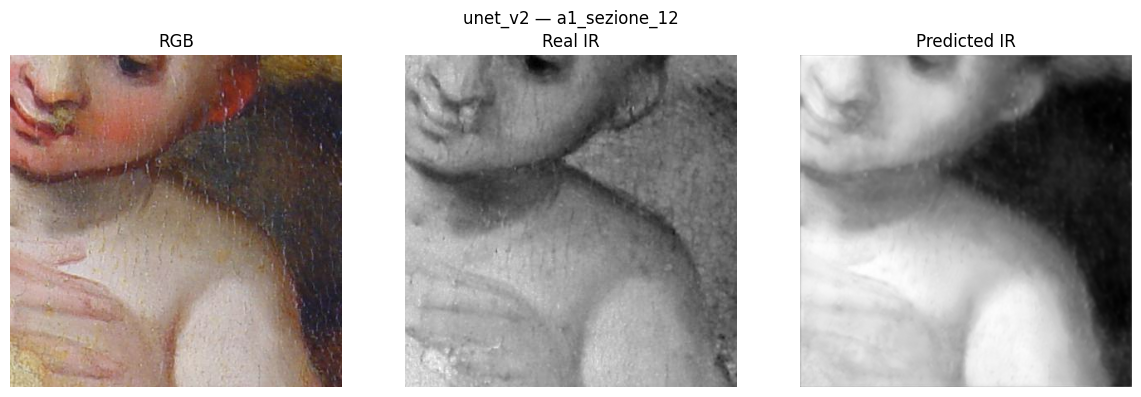

2026-08-13 22:52:31.965989: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



--- unet_restormer ---


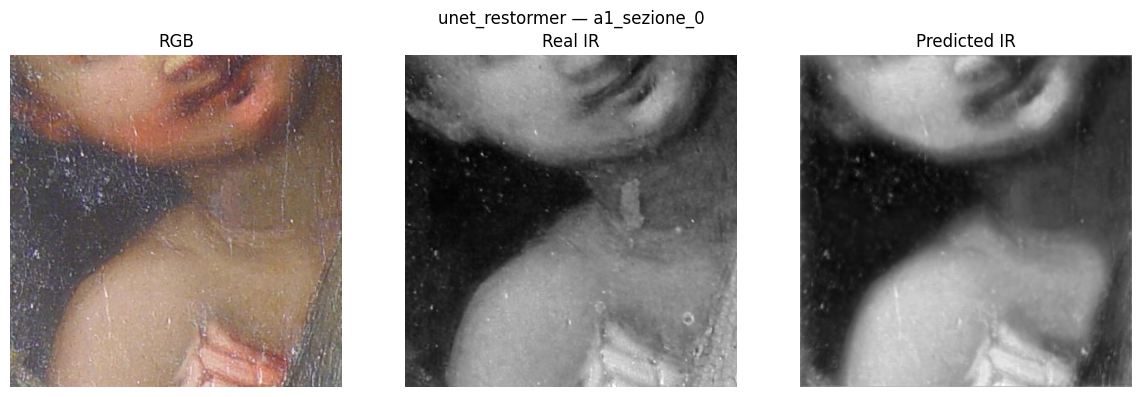

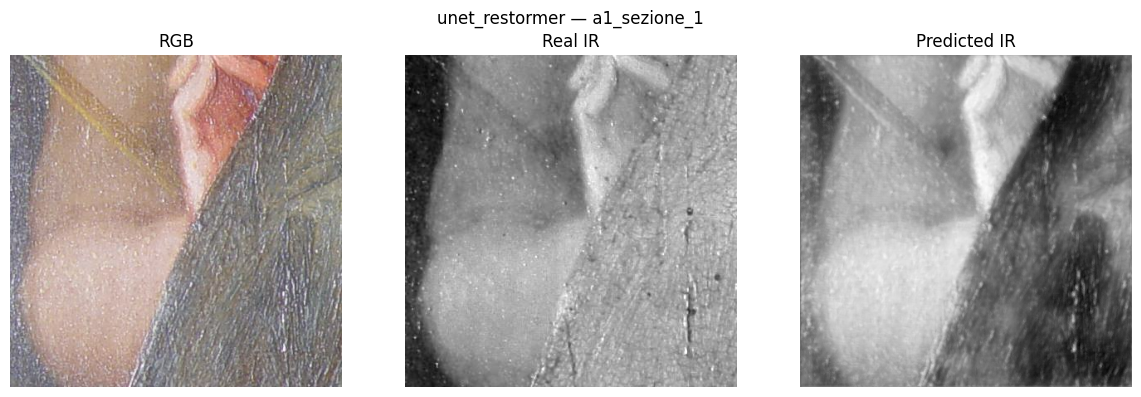

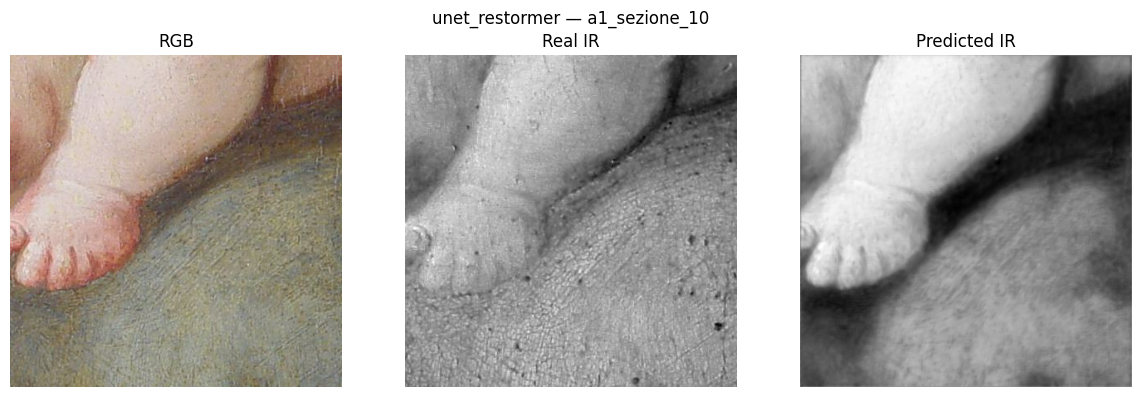

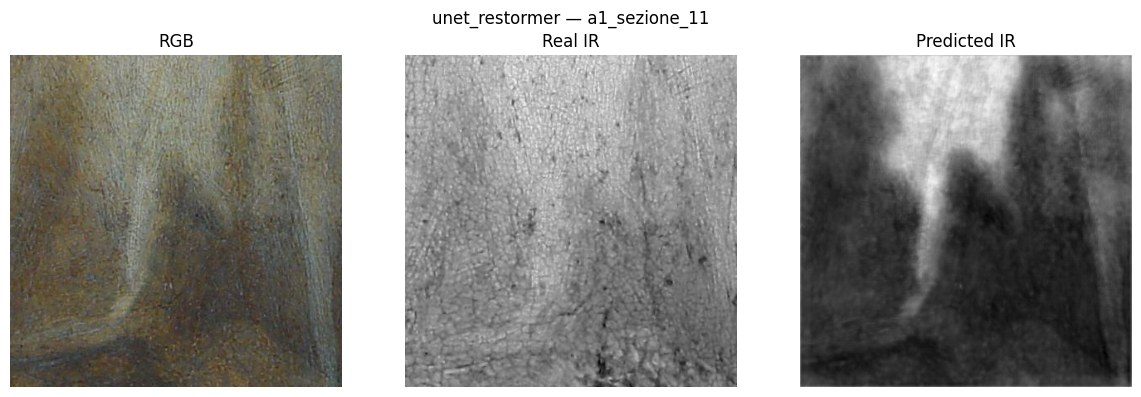

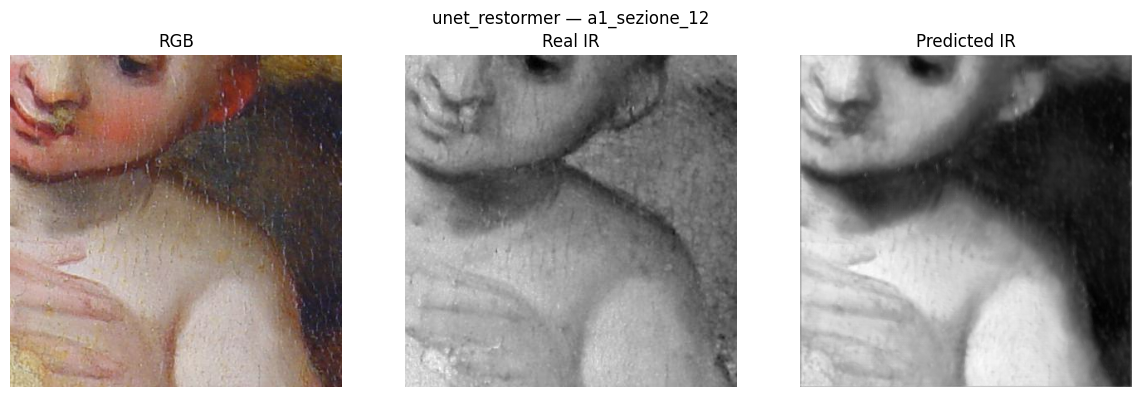

2026-08-13 22:52:34.464587: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
N_DISPLAY = 5

for arch in ["unet_v2", "unet_restormer"]:
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    print(f"\n--- {arch} ---")
    sample_ds = build_dataset(
        test_pairs[:N_DISPLAY], batch_size=1, augment=False, shuffle=False
    )
    for (rgb_batch, ir_batch), pair in zip(sample_ds, test_pairs[:N_DISPLAY]):
        ir_pred = model.predict(rgb_batch, verbose=0)
        fig = plot_predictions(
            rgb_batch[0].numpy(),
            ir_batch[0].numpy(),
            ir_pred[0],
            title=f"{arch} — {Path(pair[0]).stem}",
        )
        plt.show()

## 9. Worst predictions (lowest SSIM) — unet_v2 / unet_restormer


--- unet_v2: 3 worst predictions (SSIM) ---


2026-08-13 22:52:44.221570: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


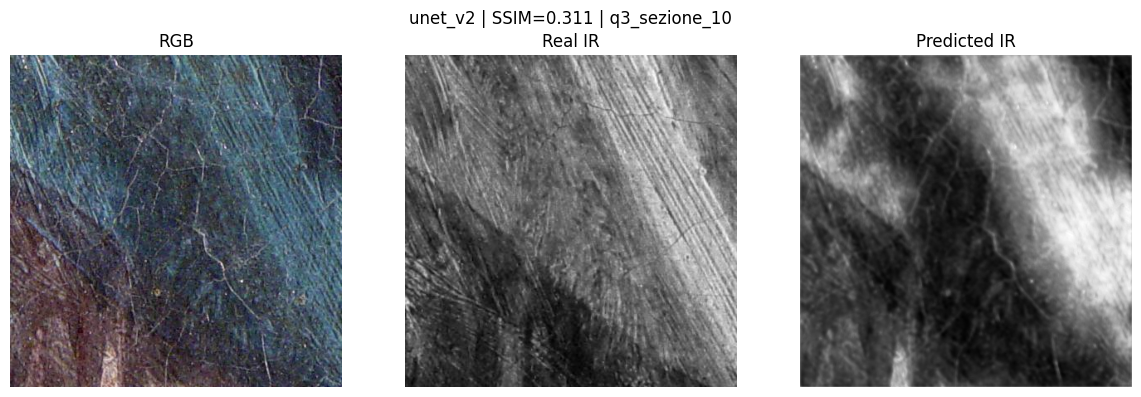

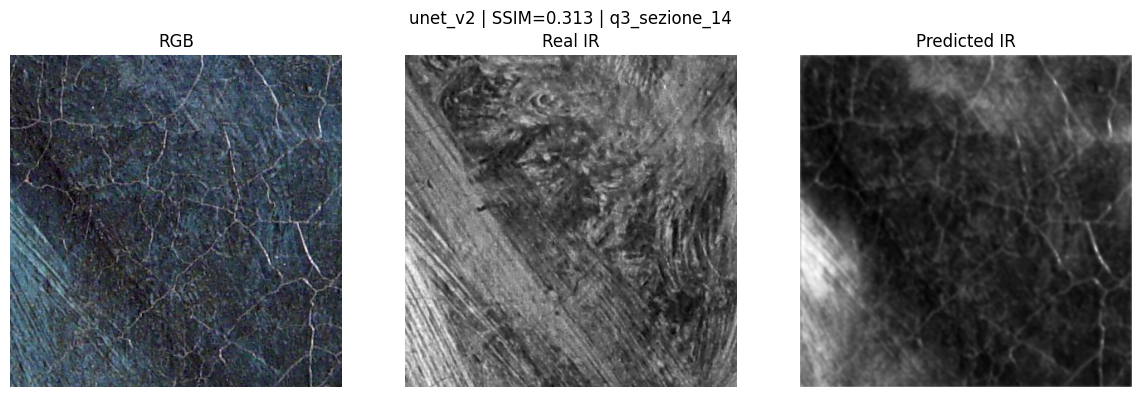

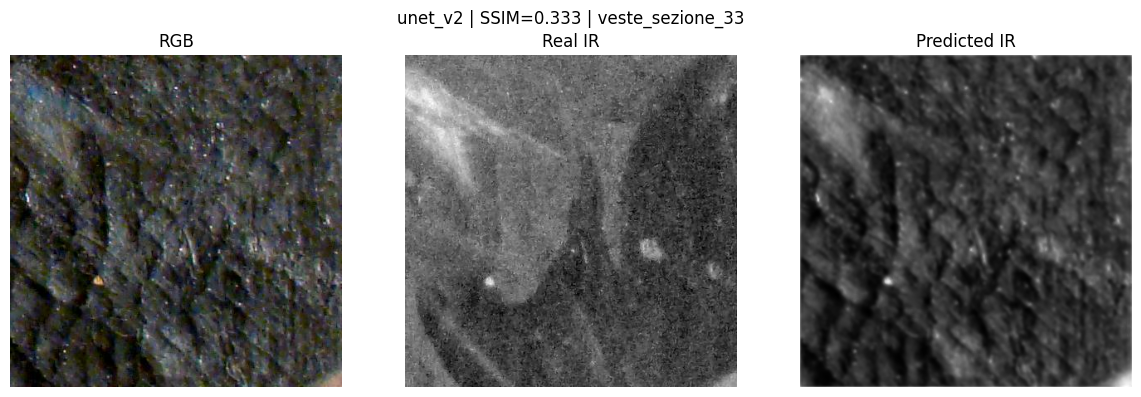


--- unet_restormer: 3 worst predictions (SSIM) ---


2026-08-13 22:52:54.041152: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


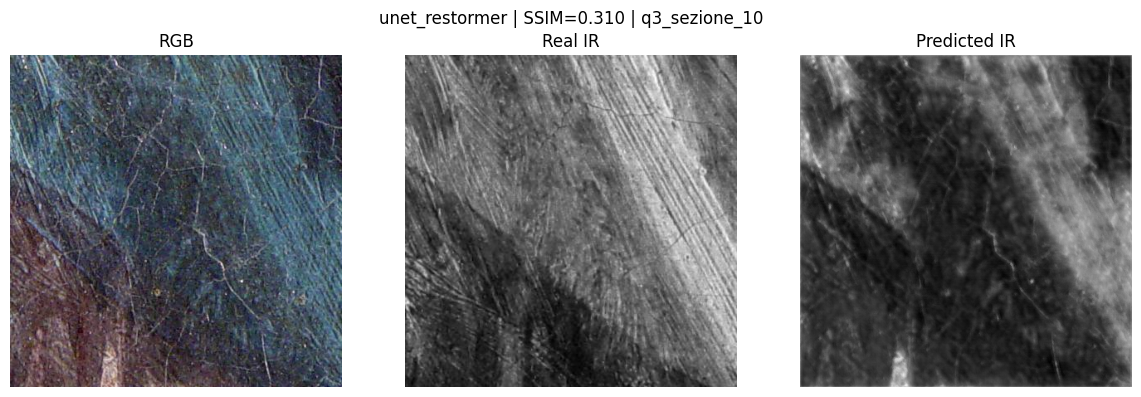

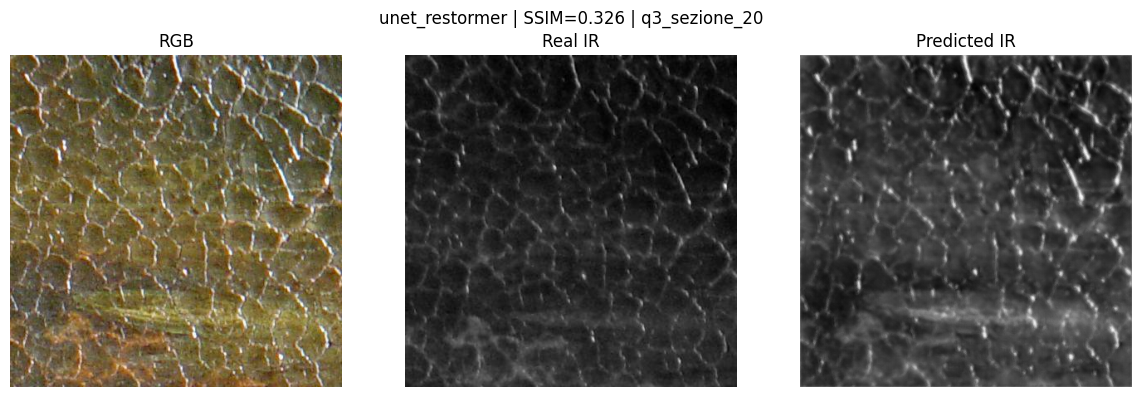

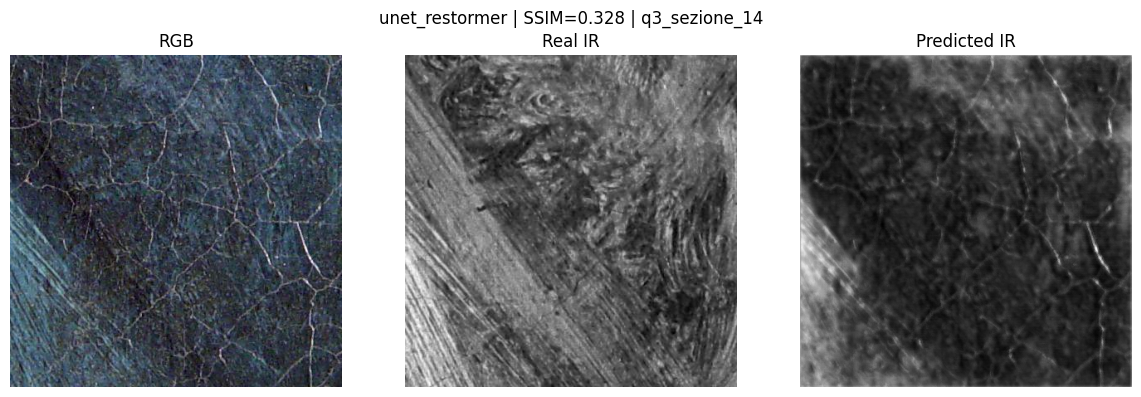

In [11]:
N_WORST = 3

for arch in ["unet_v2", "unet_restormer"]:
    try:
        model = load_model(
            arch,
            model_dir=settings.MODELS_DIR,
            lr=settings.LEARNING_RATE,
            loss_alpha=settings.LOSS_ALPHA,
        )
    except FileNotFoundError as exc:
        print(f"[skip] {exc}")
        continue

    ssim_scores: list[tuple[float, int]] = []
    single_ds = build_dataset(test_pairs, batch_size=1, augment=False, shuffle=False)

    for idx, (rgb_batch, ir_batch) in enumerate(single_ds):
        ir_pred = model.predict(rgb_batch, verbose=0)
        ssim_val = float(
            tf.reduce_mean(tf.image.ssim(ir_batch, tf.constant(ir_pred), max_val=1.0))
        )
        ssim_scores.append((ssim_val, idx))

    worst = sorted(ssim_scores)[:N_WORST]
    print(f"\n--- {arch}: {N_WORST} worst predictions (SSIM) ---")
    for ssim_val, idx in worst:
        rgb_path, ir_path = test_pairs[idx]
        rgb_batch, ir_batch = next(iter(build_dataset([test_pairs[idx]], batch_size=1)))
        ir_pred = model.predict(rgb_batch, verbose=0)
        fig = plot_predictions(
            rgb_batch[0].numpy(),
            ir_batch[0].numpy(),
            ir_pred[0],
            title=f"{arch} | SSIM={ssim_val:.3f} | {Path(rgb_path).stem}",
        )
        plt.show()